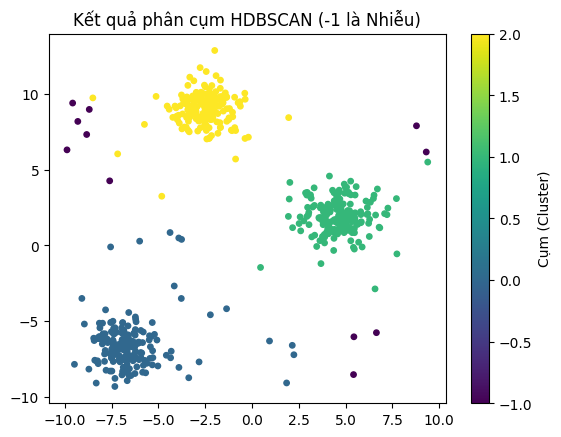

In [1]:
import hdbscan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Tạo dữ liệu mẫu (3 cụm rõ ràng)
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42)

# Thêm một chút nhiễu (noise) ngẫu nhiên vào dữ liệu
np.random.seed(42)
noise = np.random.uniform(low=-10, high=10, size=(50, 2))
X = np.vstack([X, noise])

# 2. Khởi tạo thuật toán HDBSCAN
# min_cluster_size là tham số quan trọng nhất: số điểm tối thiểu để tạo thành 1 cụm
clusterer = hdbscan.HDBSCAN(min_cluster_size=15)

# 3. Huấn luyện và dự đoán
cluster_labels = clusterer.fit_predict(X)

# 4. Vẽ biểu đồ trực quan
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', s=15)
plt.colorbar(label='Cụm (Cluster)')
plt.title('Kết quả phân cụm HDBSCAN (-1 là Nhiễu)')
plt.show()

In [2]:
# 1. Nhãn phân cụm (Labels)
# Các điểm thuộc cụm sẽ được đánh số 0, 1, 2...
# Các điểm dị biệt (noise/outliers) SẼ LUÔN LÀ -1
labels = clusterer.labels_
print(f"Số lượng điểm bị coi là nhiễu: {list(labels).count(-1)}")

# 2. Xác suất phân cụm (Probabilities)
# Cho biết thuật toán "tự tin" bao nhiêu % khi gán điểm đó vào cụm hiện tại.
# Giá trị từ 0 đến 1 (1 là rất tự tin, 0 là phân vân). Những điểm nhiễu có xác suất = 0.
probs = clusterer.probabilities_
print(f"Xác suất trung bình của các điểm trong cụm: {probs[labels != -1].mean():.2f}")

# 3. Điểm Dị biệt (Outlier Scores - GLOSH score)
# HDBSCAN là một thuật toán tìm Outlier cực đỉnh. 
# Giá trị từ 0 (rất bình thường) đến 1 (chắc chắn là điểm dị biệt).
outlier_scores = clusterer.outlier_scores_

Số lượng điểm bị coi là nhiễu: 11
Xác suất trung bình của các điểm trong cụm: 0.66


In [3]:
# Giả sử bạn có 3 điểm dữ liệu hoàn toàn mới
new_data_points = np.array([[0, 0], [5, 5], [-5, 5]])

# Yêu cầu: prediction_data=True phải được bật khi khởi tạo mô hình ban đầu
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, prediction_data=True)
clusterer.fit(X)

# Dự đoán nhãn và xác suất cho điểm mới
new_labels, new_probs = hdbscan.approximate_predict(clusterer, new_data_points)

print("Nhãn điểm mới:", new_labels)
print("Độ tự tin:", new_probs)

Nhãn điểm mới: [1 1 2]
Độ tự tin: [0.10628677 0.21439578 0.12719677]
